## Variance in Linear Regression

The goal of this notebook is to show how various levels of variance in the dataset can affect the performance of a linear regression model trained with SGD.

In [127]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

In [128]:
"""Generate dataset helper"""

import numpy as np

MIN = -7
MAX = 7
SEED = 777


def generate_sample(size: int, noise: float, seed:float = SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)

    x = rng.uniform(MIN, MAX, size)
    y = f(x) + rng.standard_normal(x.shape[0]) * noise

    return np.stack([x, y]).T

def generate_dataset(size: int, sample_size: int, noise_upto: float, seed:float = SEED) -> np.ndarray:
    datasets: list[np.ndarray] = []

    for noise in np.linspace(0, noise_upto, size):
        sample = generate_sample(sample_size, noise, seed)
        datasets.append(sample)
        seed += 1

    return np.stack(datasets[:])

In [129]:
"""Plot data helper"""

from matplotlib.figure import Figure
import matplotlib.pyplot as plt

def generate_axs(dataset_size: np.ndarray, axis:int = 0) -> None:
    row = int(np.floor(np.sqrt(dataset_size)))
    col = int(np.ceil(dataset_size/row))    
    fig, axs = plt.subplots(row, col, figsize=(16, 7))

    return fig, axs

def scatter_sample(X:np.ndarray, fig: Figure, axs: np.ndarray, color:str='blue') -> None:
    axs = axs.flatten()[:X.shape[0]]
    
    for i, ax in enumerate(axs):
        ax.scatter(X[i, :, 0], X[i, :, 1], color=color)

def plot_sample(X:np.ndarray, fig: Figure, axs: np.ndarray, color:str='red') -> None:
    axs = axs.flatten()[:X.shape[0]]
    
    for i, ax in enumerate(axs):
        ax.plot(X[i, :, 0], X[i, :, 1], color=color)


## How data are build
 
The datasets builds with `generate_dataset` function has structuraly higher variance along `axis=0`.
Variance increases is computed generating an array of equally spaced values between `0` and `noise_upto` and adding it to the `y` values of the dataset. The higher the `noise_upto` value, the higher the variance in the dataset.

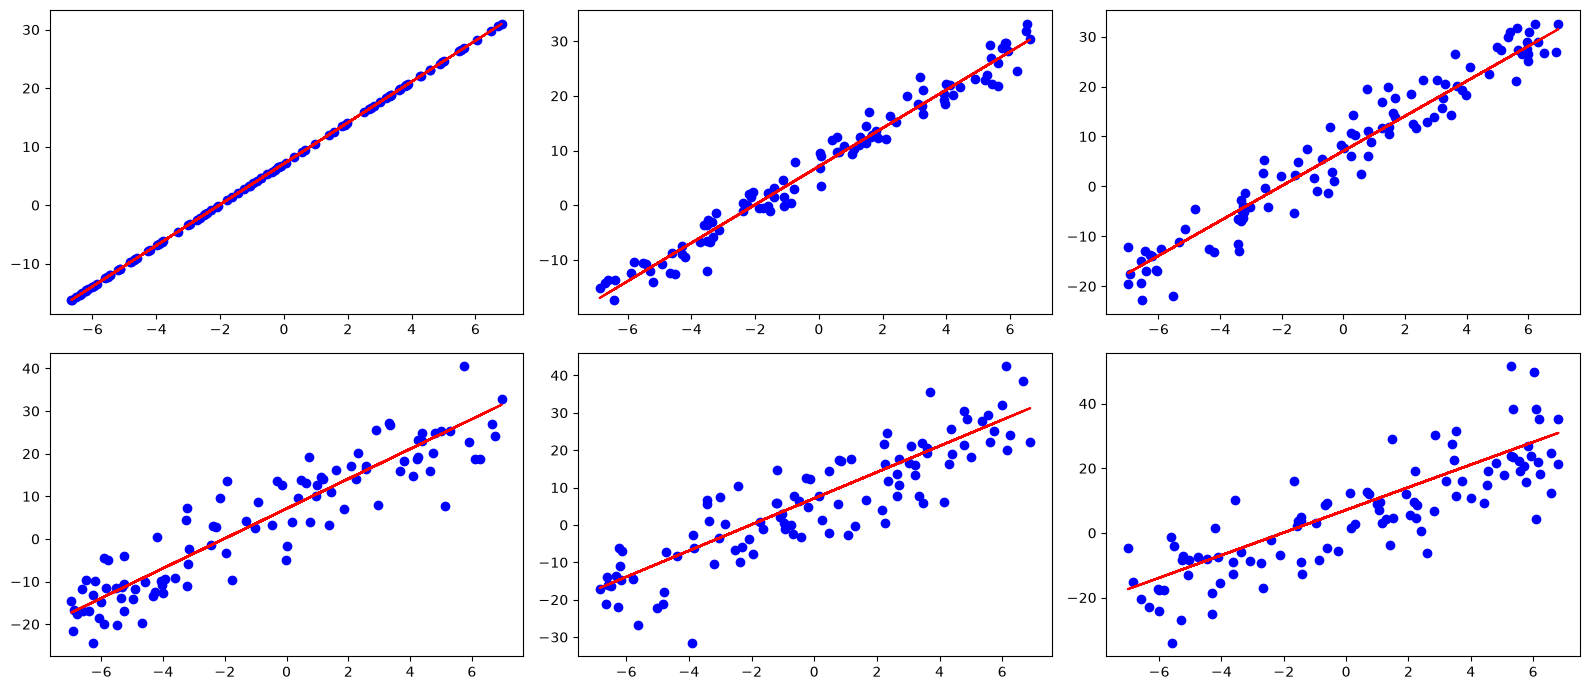

In [130]:
SAMPLE_SIZE = 100
DATASETS_SIZE = 6

X = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=10)
X_clean = generate_dataset(size=DATASETS_SIZE, sample_size=SAMPLE_SIZE, noise_upto=0)

fig, axs = generate_axs(X.shape[0])
scatter_sample(X, fig, axs)
plot_sample(X_clean, fig, axs)

fig.tight_layout()
plt.show()

In [ ]:
"""Helpers to create and train a model over a set of samples"""

from core.dataset.dataset import DataLoader
from core.layers import Linear, Sequential
from core.losses import MSELoss
from core.optimizer import SGD
from core.tensor import Tensor
from core.training.schedulers import CosineSchedule
from core.training.trainer import Trainer

EPOCHS = 300
EVAL_STEP = 10
MAX_LR, MIN_LR = 1e-2, 1e-4

def split_dataset(X:np.ndarray, split_ratio:float = 0.9) -> tuple[np.ndarray, np.ndarray]:
    """Split in train and test dataset"""
    split_idx = int(X.shape[0]*split_ratio)
    
    X0, X1 = X[:, split_idx:], X[:, :split_idx]

    return X0, X1

def create_trainer(in_feature: int, out_feature:int) -> Trainer:
    """Helper to build model, loss, optimizer, scheduler and finally the trainer"""
    model = Sequential(
        Linear(in_feature, out_feature)
    )
    loss = MSELoss()
    optimizer = SGD(model.parameters, MAX_LR)
    scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
    trainer = Trainer(model, loss, optimizer, scheduler)

    return trainer

def train_sample(trainer: Trainer, X_tr: Tensor, X_te: Tensor) -> None:
    """Helper to train a model over a sample"""
    X_tr, X_te = DataLoader(X_tr), DataLoader(X_te)

    for i in range(EPOCHS):
        _ = trainer.train_epoch(X_tr)

        if i % EVAL_STEP == 0:
            _ = trainer.eval(X_te)

def train_dataset(trainers: list[Trainer], dataset_tr: DataLoader, dataset_te: DataLoader) -> None:
    """Helper to train a set of models over the complete dataset"""

    for trainer, sample_tr, sample_te in enumerate(zip(trainers, dataset_tr, dataset_te)):
        train_sample(trainer, sample_tr, sample_te)

In [132]:
trainers: list[Trainer] = []

X_tr, X_te = split_dataset(X)
print(X_tr.shape, X_te.shape)

for i in range(DATASETS_SIZE):
    trainers.append(create_trainer(X.shape[2], X.shape[2]))

(6, 95, 2) (6, 5, 2)
